# Предсказание веса черепахи по размерам

Задача: Предсказание массы черепахи по её характеристикам с помощью линейной регрессии

## Постановка задачи машинного обучения

- Тип задачи: регрессия

- Целевая переменная:
  `weight` - масса черепахи (кг)

- Метрики качества:
  - MAE - средняя абсолютная ошибка
  - MAPE - средняя относительная ошибка (%)
  - R² - коэффициент детерминации

- Критерии успешности:
  - MAE ≤ 5 кг (для взрослых особей 50–150 кг)
  - Низкое значение MAPE (учёт относительной ошибки на разных масштабах)
  - R² ≥ 0.97 на валидационной и тестовой выборках
  - Модель корректно работает для черепах разного возраста и размера

## Подключение и настройка библиотек

In [51]:
!pip install numpy pandas scikit-learn seaborn

In [52]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

In [53]:
mpl.rcParams['figure.constrained_layout.use'] = True

## Загрузка датасета

- Загрузите данные из файла `turtles.csv`, путь к файлу: `'/datasets/turtles.csv'`. При использовании метода [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) установите правильные значения для параметров `sep` и `decimal`: в качестве разделителя столбцов используйте символ табуляции (`'\t'`), а в качестве разделителя дробной части - запятую.
- Проверьте, правильно ли прошла загрузка. Данные должны соответствовать описанию в тексте урока.
- С помощью методов библиотеки pandas выведите общие сведения о данных.
- Возможно ли продолжать работу? Если нет - что нужно сделать, чтобы устранить препятствия?

In [54]:
# Импорт данных
data = pd.read_csv('https://code.s3.yandex.net/datasets/turtles.csv', sep='\t', decimal=',')
data.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
0,20438,Caretta caretta,d89af72662f49ece4d09dec75a8b0166,700.0,381,112.0,82.0,356,205,331,185,270.0,180.0,273.0,144.0,63,3.0,NaN,1703159226,87.687
1,19034,Lepidochelys olivacea,1579c64777de4db1c16e8b7b0d19c45e,341.0,295,65.0,48.0,216,190,229,186,164.0,182.0,180.0,149.0,0,1.0,1.0,1689428175,26.949
2,24689,LEPIDOCHELYS OLIVACEA,bfcec01187569615087e4d777c44985a,408.0,343,71.0,70.0,308,224,285,232,264.0,179.0,268.0,176.0,0,3.0,NaN,1745783111,30.016
3,17945,Lepidochelys Olivacea,2c159675aa28f0ea566fce2090bf4c82,512.0,432,98.0,95.0,334,317,364,284,NaN,NaN,NaN,NaN,3,4.0,1.0,1677757151,33.917
4,24543,lepidochelys olivacea,ecd22499761e2ac56a6d8eb765ec566d,408.0,307,50.0,54.0,280,168,269,218,199.0,165.0,209.0,180.0,0,4.0,1.0,1744455613,28.511


In [55]:
# Вывод информации о столбцах
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   str    
 2   registration number  8832 non-null   str    
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   int64  
 16 

In [56]:
# Проверка значений в столбце shell_crack
data['shell_crack'].value_counts(dropna=False)

shell_crack
NaN    6685
1.0    1442
2.0     322
3.0     208
5.0     111
4.0      93
Name: count, dtype: int64

Промежуточный вывод

Работу можно продолжать:

- данные успешно загружены
- структура корректная
- критических проблем (битые строки, неверные типы, массовые пропуски) не обнаружено
    - Пропуски в столбце shell_crack обозначают отсутствие трещины

## Исследовательский анализ данных

Проведите исследовательский анализ данных:
1. Выясните, данные о каких черепахах представлены в датасете.
2. Проведите отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только *Chelonia mydas*. При этом вы можете сравнить распределение данных об этих черепахах с другими видами, если есть желание и время.
3. Определите, все ли признаки можно использовать для решения задачи. Ответ обоснуйте. Удалите признаки, которые вам никак не помогут.
4. Проверьте, есть ли в данных пропуски. Определите, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки. Решите, стоит ли удалить некоторые пропуски.
5. Определите, есть ли в данных дубликаты. Выберите корректный способ их обработки.
6. Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить.
7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

### 1. Выясните, данные о каких черепахах представлены в датасете.

In [57]:
# Виды черепах в данных
data['binomial_name'].value_counts(dropna=False)

binomial_name
Lepidochelys olivacea     3372
Chelonia mydas            2325
Caretta caretta            674
lepidochelys olivacea      416
Dermochelys coriacea       399
Eretmochelys imbricata     332
Lepidochelys Olivacea      285
chelonia mydas             252
Chelonia Mydas             177
LEPIDOCHELYS OLIVACEA      142
caretta caretta             90
CHELONIA MYDAS              75
NaN                         49
Caretta Caretta             46
eretmochelys imbricata      41
dermochelys coriacea        40
CARETTA CARETTA             37
Eretmochelys Imbricata      28
Dermochelys Coriacea        27
Lepidochelys kempii         22
DERMOCHELYS CORIACEA        18
ERETMOCHELYS IMBRICATA       8
lepidochelys kempii          3
Lepidochelys Kempii          3
Name: count, dtype: int64

Требуется привести названия черепах к одному виду

In [58]:
# Приведение названий к нижнему регистру
data['binomial_name'] = data['binomial_name'].str.lower()

In [59]:
# Названия черепах в данных после приведения к одному виду записи
data['binomial_name'].value_counts(dropna=False)

binomial_name
lepidochelys olivacea     4215
chelonia mydas            2829
caretta caretta            847
dermochelys coriacea       484
eretmochelys imbricata     409
NaN                         49
lepidochelys kempii         28
Name: count, dtype: int64

### 2. Определите, есть ли в данных дубликаты

Сначала проверим данные на явные дубликаты

In [60]:
# Подсчет количества явных дубликатов и их доли
duplicates_len = data.duplicated().sum()

duplicates_len, duplicates_len / len(data)

(np.int64(1019), np.float64(0.11499830718880487))

In [61]:
# Удаление явных дубликатов
data = data.drop_duplicates()

Проверим, остались ли дубликаты по id

In [62]:
# Получение дубликатов id
data['id'].duplicated().sum()

np.int64(0)

Явных дубликатов не осталось. Удалено 1019 строк (11.5%)

Неявные дубликаты в данных отсутствуют

### 3. Проведите отбор записей о нужном виде черепах

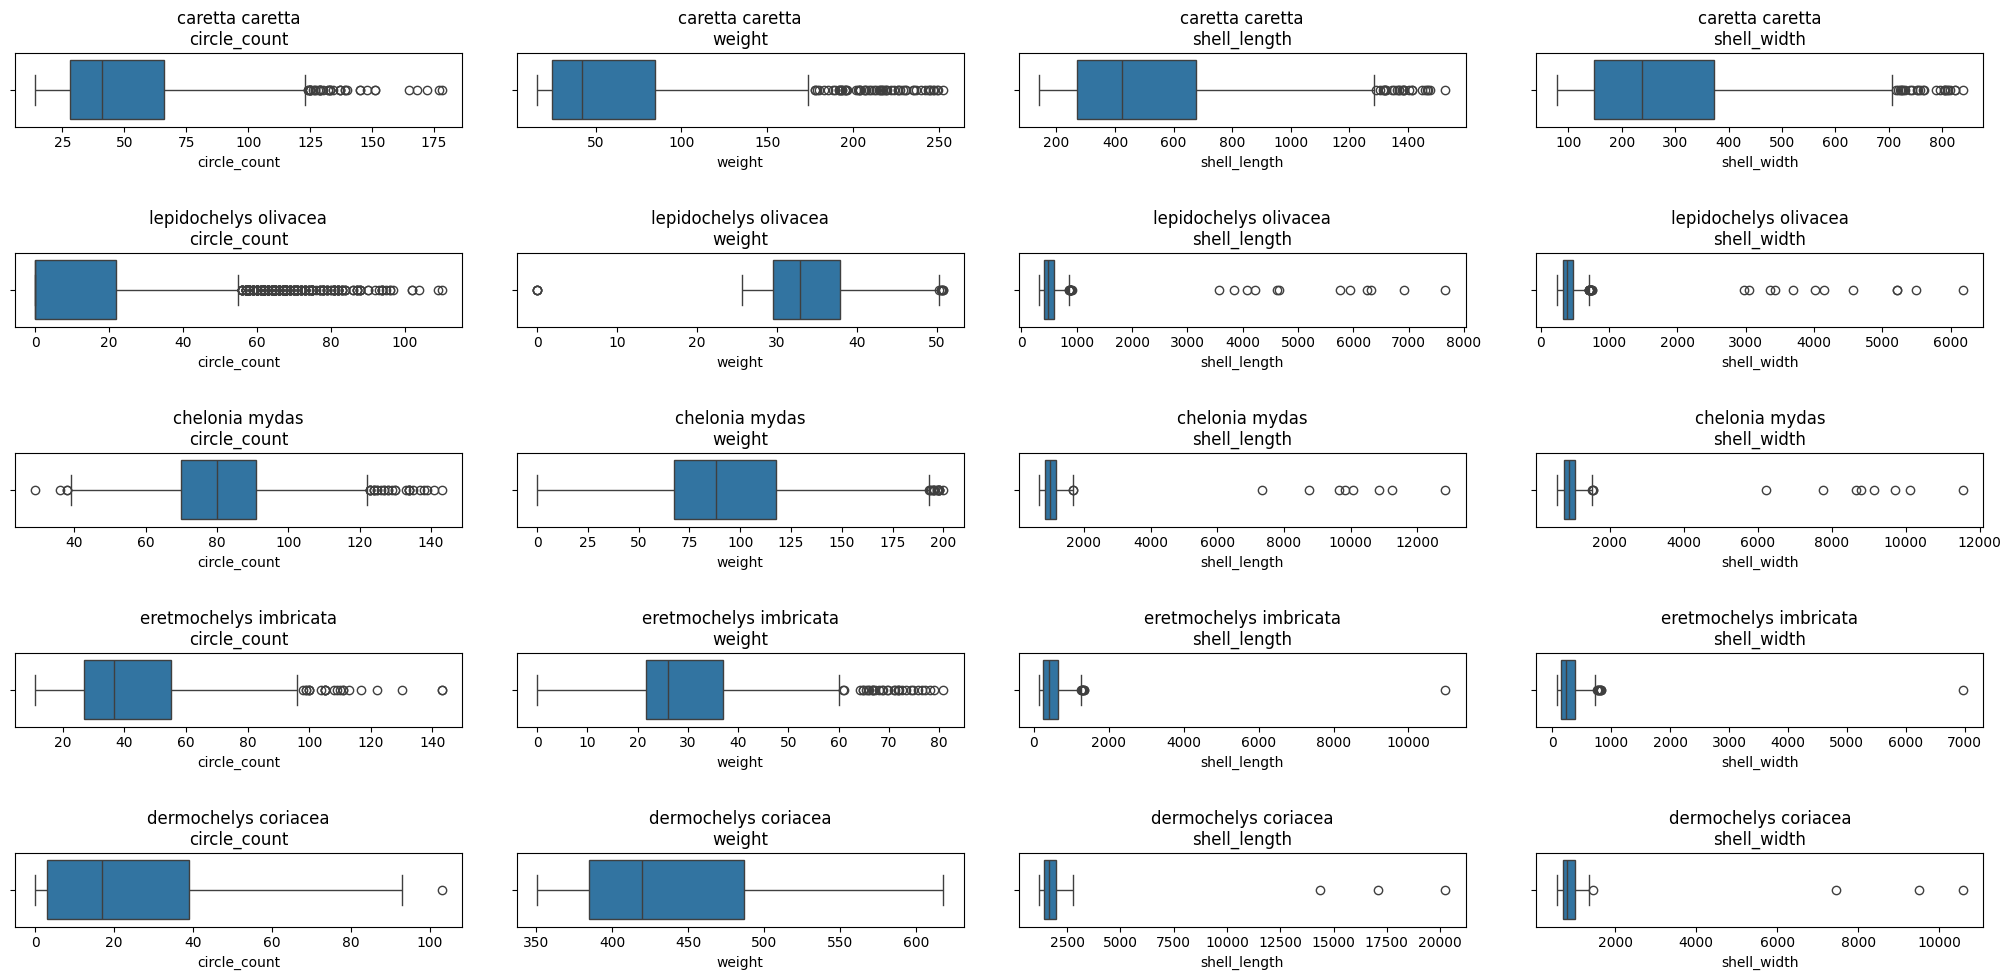

In [63]:
# Проанализируем с помощью графиков данные разных видов черепах.

# Отбросим данные с Nan названием и с количеством черепах < 100 (lepidochelys kempii)
turtle_kinds = data['binomial_name'].unique()
turtle_kinds = turtle_kinds[(~pd.isna(turtle_kinds)) & (turtle_kinds != 'lepidochelys kempii')]

params = ['circle_count', 'weight', 'shell_length', 'shell_width']

fig, axes = plt.subplots(
    len(turtle_kinds),
    len(params),
    figsize=(len(params) * 5,  len(turtle_kinds) * 2)
)

for row, turtle_kind in enumerate(turtle_kinds):
    for col, param in enumerate(params):
        sns.boxplot(
            data=data[data['binomial_name'] == turtle_kind],
            x=param,
            ax=axes[row][col],
        )
        axes[row][col].set_title(f'{turtle_kind}\n{param}')

fig.set_constrained_layout_pads(h_pad=0.2, hspace=0.2, wspace=0.1)
plt.show()


По circle_count, weight, shell_length и shell_width виды черепах заметно различаются, и эти различия сохраняются даже при наличии выбросов; распределения отличаются по форме и масштабу, поэтому одна модель на все виды даст смещение, логично строить отдельные модели, а в текущем задании используем только chelonia mydas

In [64]:
# Выделяем данные вида Chelonia mydas
data_cm = data[data['binomial_name']=='chelonia mydas']
data_cm.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
8,25241,chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,4.0,1.0,1751228603,56.352
11,20099,chelonia mydas,36e7d3b61a0d557e45ad4b39bb2ec512,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,2.0,5.0,1699913950,154.074
16,18213,chelonia mydas,cbb98eb064c1dcefd1a009b21656500f,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,1.0,NaN,1680303901,87.695
20,20656,chelonia mydas,0da9da7f4ed73816b8967c7fe87fc4f5,703.0,606,NaN,NaN,355,382,411,340,302.0,355.0,314.0,283.0,62,3.0,1.0,1705325532,51.182
21,20839,chelonia mydas,8c20d754391001ef4cda77701123f4bc,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,2.0,NaN,1707227368,92.707


### 4. Определите, все ли признаки можно использовать для решения задачи

In [65]:
# Проверка представлена ли каждая черепаха в замерах только 1 раз
print(f"Уникальных черепах: {data_cm['id'].nunique()}, всего записей: {len(data_cm['id'])}")

Уникальных черепах: 2488, всего записей: 2488


Для построения модели используются не все признаки датасета. Следующие признаки необходимо удалить:

- `id` - уникальный идентификатор черепахи. Не содержит информации о закономерностях веса и может привести к переобучению
- `binomial_name` - научное название вида. В рамках задачи рассматривается один вид, поэтому признак является константным
- `registration_number` - регистрационный номер. Не связан с весом и может привести к переобучению
- `measure_count` - количество измерений. Не влияет на итоговый вес, если считаем его корректно измеренным
- `timestamp` - время записи данных. В задаче отсутствует временная зависимость

In [66]:
data_cm.head()

,id,binomial_name,registration number,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
8,25241,chelonia mydas,0d05dca974d9f624d9c9f8e38817f827,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,4.0,1.0,1751228603,56.352
11,20099,chelonia mydas,36e7d3b61a0d557e45ad4b39bb2ec512,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,2.0,5.0,1699913950,154.074
16,18213,chelonia mydas,cbb98eb064c1dcefd1a009b21656500f,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,1.0,NaN,1680303901,87.695
20,20656,chelonia mydas,0da9da7f4ed73816b8967c7fe87fc4f5,703.0,606,NaN,NaN,355,382,411,340,302.0,355.0,314.0,283.0,62,3.0,1.0,1705325532,51.182
21,20839,chelonia mydas,8c20d754391001ef4cda77701123f4bc,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,2.0,NaN,1707227368,92.707


In [67]:
# Удаление лишних признаков
data_cm = data_cm.drop(columns=['id', 'binomial_name', 'registration number', 'measure_count', 'timestamp'])
data_cm.head()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
8,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,1.0,56.352
11,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,5.0,154.074
16,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,NaN,87.695
20,703.0,606,NaN,NaN,355,382,411,340,302.0,355.0,314.0,283.0,62,1.0,51.182
21,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,NaN,92.707


### 5. Проверьте, есть ли в данных пропуски.

 За пропуски будем считать не только явный `nan`, но и нулевые значения, которые невозможно получить при измерении черепах

In [68]:
# Замена всех нулей на nan
data_cm = data_cm.replace(0, np.nan)

In [69]:
# Вывод количества и доли признаков
data_cm_len = len(data_cm)

for col in data_cm.columns:
    missed_values_len = data_cm[col].isna().sum()
    missed_values_share = missed_values_len / data_cm_len
    print(f'Признак {col}: пропусков {missed_values_len}, доля пропусков {missed_values_share:.3f}')

Признак shell_length: пропусков 29, доля пропусков 0.012
Признак shell_width: пропусков 0, доля пропусков 0.000
Признак head_length: пропусков 35, доля пропусков 0.014
Признак head_width: пропусков 35, доля пропусков 0.014
Признак flipper_length_1: пропусков 0, доля пропусков 0.000
Признак flipper_width_1: пропусков 0, доля пропусков 0.000
Признак flipper_length_2: пропусков 0, доля пропусков 0.000
Признак flipper_width_2: пропусков 0, доля пропусков 0.000
Признак flipper_length_3: пропусков 29, доля пропусков 0.012
Признак flipper_width_3: пропусков 29, доля пропусков 0.012
Признак flipper_length_4: пропусков 29, доля пропусков 0.012
Признак flipper_width_4: пропусков 29, доля пропусков 0.012
Признак circle_count: пропусков 0, доля пропусков 0.000
Признак shell_crack: пропусков 1889, доля пропусков 0.759
Признак weight: пропусков 5, доля пропусков 0.002


Большое количество пропусков выявлено в признаке `shell_crack`, но как мы выяснили ранее, null значение обозначает отсутствие трещин на панцире

Заполним их сразу нулями:

In [70]:
# Заполнение пропусков в признаке shell_crack нулями
data_cm['shell_crack'] = data_cm['shell_crack'].fillna(0)
data_cm.head()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
8,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,1.0,56.352
11,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,5.0,154.074
16,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,0.0,87.695
20,703.0,606,NaN,NaN,355,382,411,340,302.0,355.0,314.0,283.0,62,1.0,51.182
21,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,0.0,92.707


Есть 5 пропусков в признаке веса - таргетной переменной. Это незначительное количество (доля около 0.002), поэтому можем удалить строки с пропуском в `weight`:

In [71]:
data_cm = data_cm[data_cm['weight'].notna()]

Изучим подробнее пропуски в других признаках:

In [72]:
data_cm.isna().sum()

shell_length        29
shell_width          0
head_length         35
head_width          35
flipper_length_1     0
flipper_width_1      0
flipper_length_2     0
flipper_width_2      0
flipper_length_3    29
flipper_width_3     29
flipper_length_4    29
flipper_width_4     29
circle_count         0
shell_crack          0
weight               0
dtype: int64

In [73]:
# Количество строк с пропусками и их доля относительно общего количества
missed_values_len = data_cm.isna().any(axis=1).sum()
missed_values_share = missed_values_len / len(data_cm)

print(f"Строк с пропусками: {missed_values_len} ({missed_values_share:.2%})")

Строк с пропусками: 90 (3.62%)


Пропуски в этих признаках заполним после разделения данных, чтобы не допустить утечку данных

### 6. Проанализируйте распределение признаков

In [74]:
# Вспомним какие столбцы у нас остались
data_cm.head()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
8,742.0,652,118.0,147.0,411,386,507,389,414.0,368.0,311.0,325.0,66,1.0,56.352
11,1336.0,1318,207.0,248.0,845,704,661,768,587.0,686.0,661.0,585.0,111,5.0,154.074
16,1010.0,926,216.0,156.0,562,488,529,432,467.0,434.0,553.0,463.0,76,0.0,87.695
20,703.0,606,NaN,NaN,355,382,411,340,302.0,355.0,314.0,283.0,62,1.0,51.182
21,982.0,940,187.0,157.0,518,557,545,463,497.0,511.0,541.0,479.0,103,0.0,92.707


Для всех признаков выведем пару графиков histplot + boxplot. Это позволит визуально оценить распределение данных и количество выбросов:

In [75]:
# Функция для построения графиков histplot + boxplot по данным
def graphs_for_allocation(df):
    fig, axes = plt.subplots(
        len(df.columns),
        2,
        figsize=(10,  len(df.columns) * 2)
    )

    for i, col in enumerate(df.columns):
        sns.histplot(
            data=df,
            x=col,
            ax=axes[i][0],
        )

        sns.boxplot(
            data=df,
            x=col,
            ax=axes[i][1],
        )

    fig.set_constrained_layout_pads(h_pad=0.2, hspace=0.2, wspace=0.1)
    plt.show()

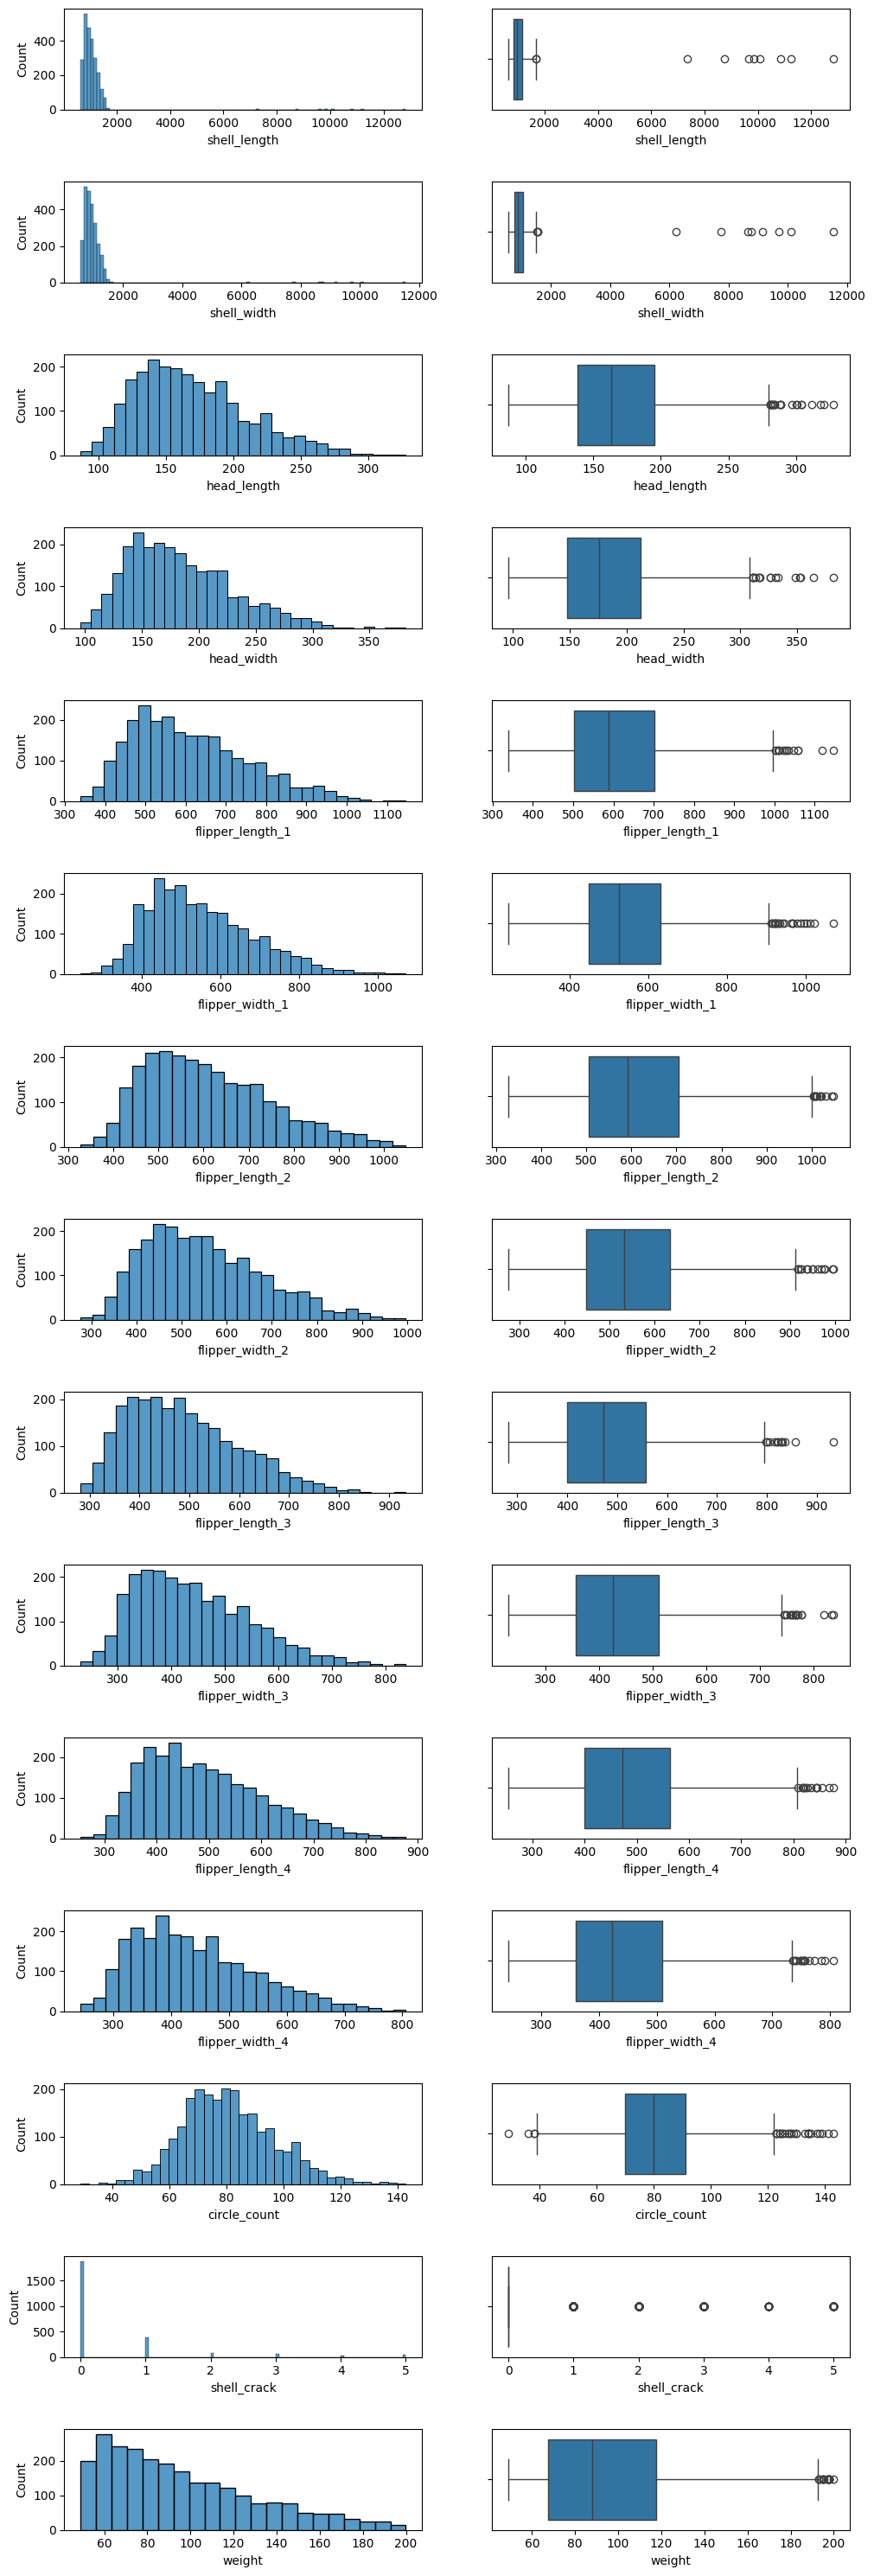

In [76]:
# Построение графиков
graphs_for_allocation(data_cm)

Явно заметны выбросы в следующих признаках:

- shell_length
- shell_width

В следующих столбцах нельзя с полной уверностью говорить о выбросах:

- head_length
- flipper_length_n
- flipper_width_n
- circle_count

В следующих столбцах выбросы маловероятны или полностью отстутствуют:

- shell_crack
- weight

Выделим наблюдения, в которых значения shell_length или shell_width превышают 99-й перцентиль, разделим их на 10 и повторно построим графики. Предполагается, что эти значения были ошибочно умножены на 10, согласно информации от коллег.

In [77]:
# Приведем типы столбцов 'shell_length', 'shell_width' к float перед делением
cols = ['shell_length', 'shell_width']
data_cm[cols] = data_cm[cols].apply(pd.to_numeric, errors='coerce', downcast='float')

# Разделим указанные ранее значения на 10
mask = (
        (data_cm['shell_length'] > data_cm['shell_length'].quantile(.99))
        & (data_cm['shell_width'] > data_cm['shell_width'].quantile(.99))
        )
data_cm.loc[mask, cols] = (data_cm.loc[mask, cols] / 10).round(2)

In [78]:
data_cm.loc[mask, cols]

,shell_length,shell_width
165,1284.000000,1155.000000
349,1124.000000,1012.000000
453,1086.000000,971.000000
478,160.699997,149.600006
1132,984.000000,915.000000
1178,160.699997,149.800003
2277,734.000000,623.000000
2712,1008.000000,866.000000
3762,162.000000,146.399994
3977,166.699997,155.100006


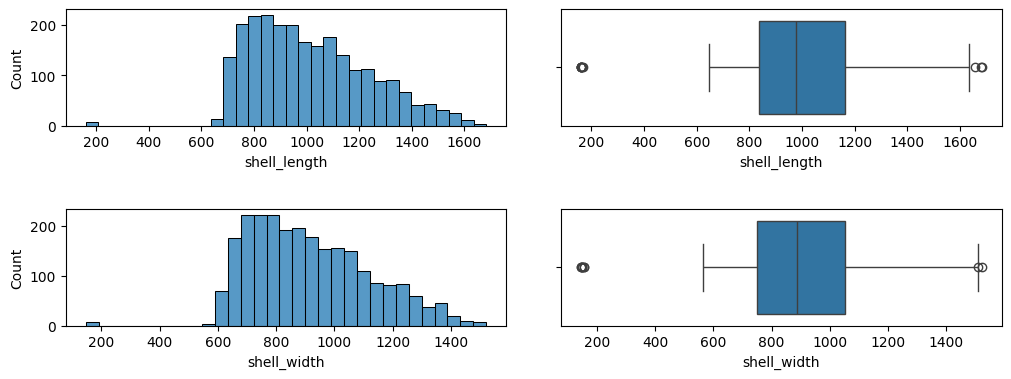

In [79]:
graphs_for_allocation(data_cm[['shell_length', 'shell_width']])

Явно выделяются выбросы в районе 150-200. Посмотрим сколько в этом диапазоне значений и уточним его

In [80]:
# Проверка выбросов

# границы левого уса
q1 = data_cm[cols].quantile(0.25)
q3 = data_cm[cols].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr

# маска: меньше левого уса хотя бы по одному столбцу
mask = (
    (data_cm['shell_length'] < lower['shell_length']) |
    (data_cm['shell_width'] < lower['shell_width'])
)

# вывод информации
(
    len(data_cm[mask]),
    len(data_cm[mask]) / len(data_cm),
    ('shell_length', data_cm.loc[mask, 'shell_length'].min(), data_cm.loc[mask, 'shell_length'].max()),
    ('shell_width', data_cm.loc[mask, 'shell_width'].min(), data_cm.loc[mask, 'shell_width'].max()),
)

(7,
 0.002819170358437374,
 ('shell_length', np.float32(160.7), np.float32(166.7)),
 ('shell_width', np.float32(146.0), np.float32(155.4)))

Выбросы затрагивают 7 строк, их можно удалить

In [81]:
data_cm = data_cm[~mask]

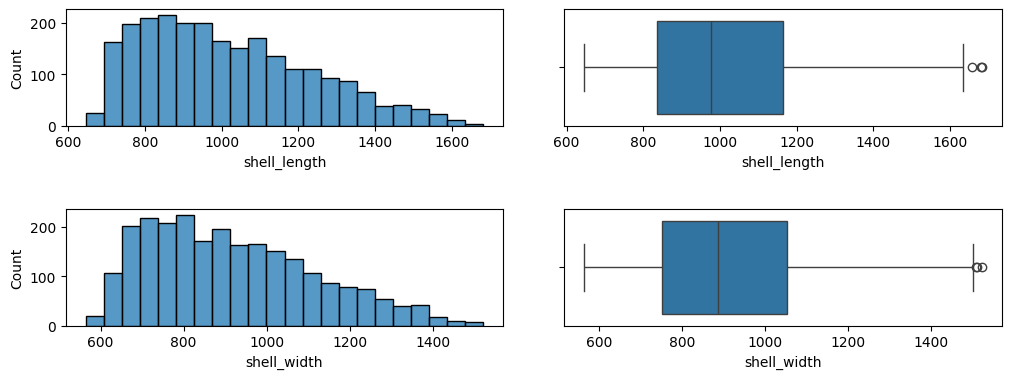

In [82]:
graphs_for_allocation(data_cm[['shell_length', 'shell_width']])

Теперь в признаках `shell_length`, `shell_width` не осталось выбросов

Повторно изучим нетронутые числовые признаки:

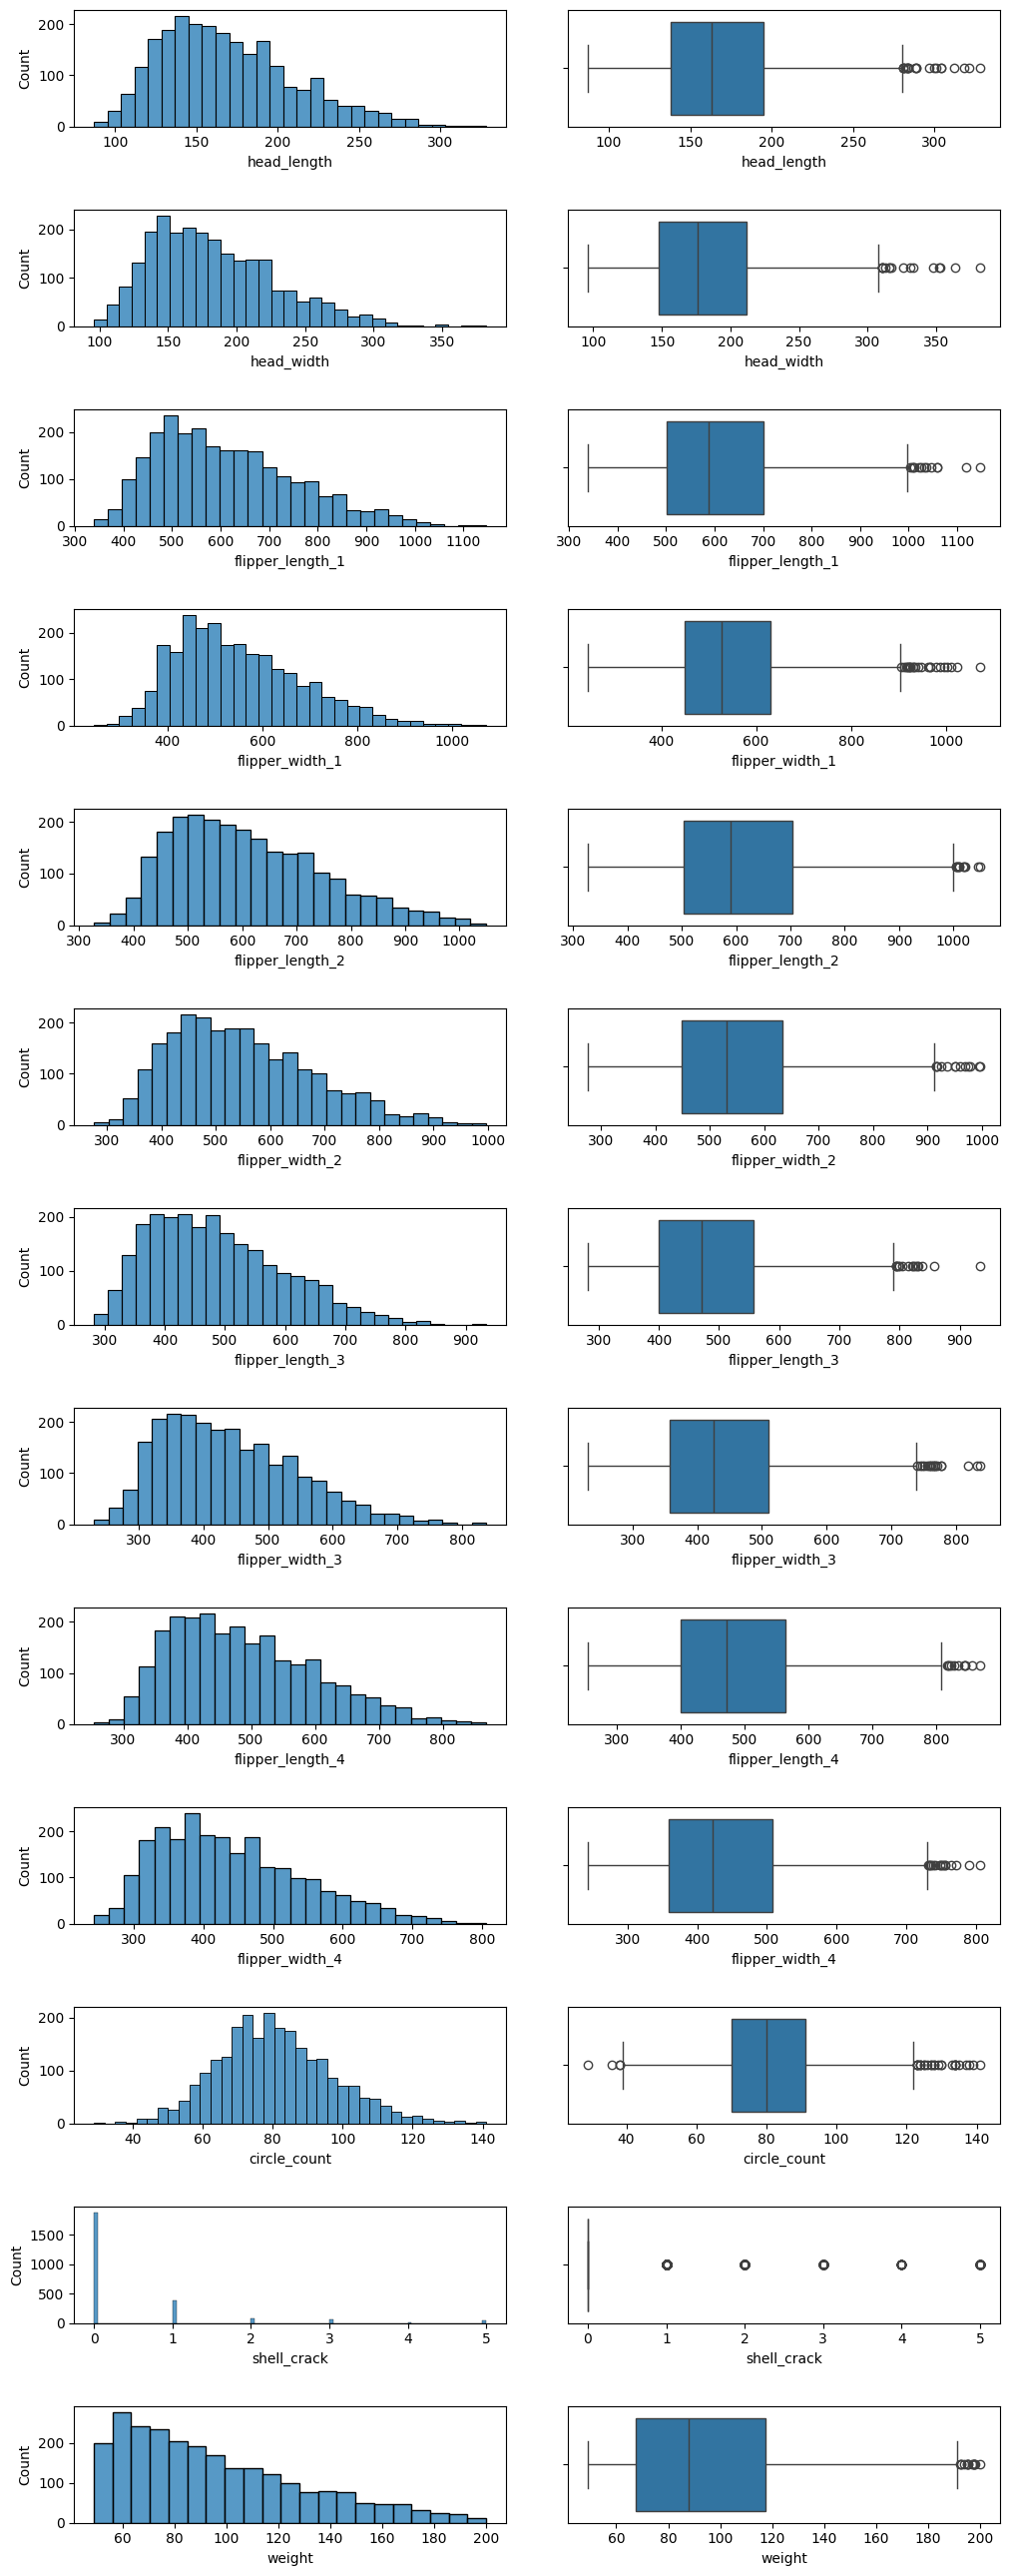

In [83]:
graphs_for_allocation(data_cm.drop(columns=['shell_length', 'shell_width']))

В оставшихся столбцах нет значительных выбросов, которые могут сигнализировать об ошибке с умножением значения на 10 или аномалиях в размерах черепах.

### 7. Проверьте, одинаков ли масштаб признаков

Вернемся к графикам из предыдущего шага. По ним можно сделать следующий вывод:

Масштаб признаков неодинаков. В среднем значения могут отличаться на порядок. А характеристика shell_crack находится в небольшом диапазоне 1-5. Поэтому необходимо провести стандартизацию признаков.

Сделаем это после разделения данных на train и test, чтобы предотвратить утечку данных

### 8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически.

Воспользуемся методом .corr для оценки характеристик между собой и целевой переменной

In [84]:
data_cm_corr = data_cm.corr()
data_cm_corr

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,shell_crack,weight
shell_length,1.000000,0.959116,0.865255,0.858944,0.919166,0.890371,0.916471,0.896354,0.915226,0.894192,0.918083,0.894846,0.500175,0.163642,0.984171
shell_width,0.959116,1.000000,0.849419,0.841973,0.903312,0.875856,0.904617,0.882974,0.901500,0.879633,0.901507,0.883532,0.495496,0.162136,0.968033
head_length,0.865255,0.849419,1.000000,0.760685,0.810580,0.786598,0.812418,0.793445,0.809160,0.790591,0.808069,0.801723,0.450676,0.126674,0.873625
head_width,0.858944,0.841973,0.760685,1.000000,0.806760,0.778899,0.804326,0.788604,0.800815,0.784352,0.815741,0.794297,0.443058,0.134076,0.867018
flipper_length_1,0.919166,0.903312,0.810580,0.806760,1.000000,0.835061,0.867660,0.848589,0.855482,0.840142,0.864013,0.838505,0.472624,0.157379,0.926841
flipper_width_1,0.890371,0.875856,0.786598,0.778899,0.835061,1.000000,0.832279,0.816933,0.833783,0.816197,0.834106,0.812762,0.477534,0.156494,0.896822
flipper_length_2,0.916471,0.904617,0.812418,0.804326,0.867660,0.832279,1.000000,0.840125,0.857480,0.839735,0.855822,0.841053,0.468039,0.160445,0.923030
flipper_width_2,0.896354,0.882974,0.793445,0.788604,0.848589,0.816933,0.840125,1.000000,0.840162,0.822834,0.845284,0.816631,0.460997,0.165270,0.901481
flipper_length_3,0.915226,0.901500,0.809160,0.800815,0.855482,0.833783,0.857480,0.840162,1.000000,0.841065,0.864476,0.840549,0.466453,0.160864,0.922166
flipper_width_3,0.894192,0.879633,0.790591,0.784352,0.840142,0.816197,0.839735,0.822834,0.841065,1.000000,0.844607,0.821267,0.457193,0.152549,0.900898


Даже при просмотре коэффициентов корреляции заметно большое количество больших значений. Для наглядности построим тепловую карту

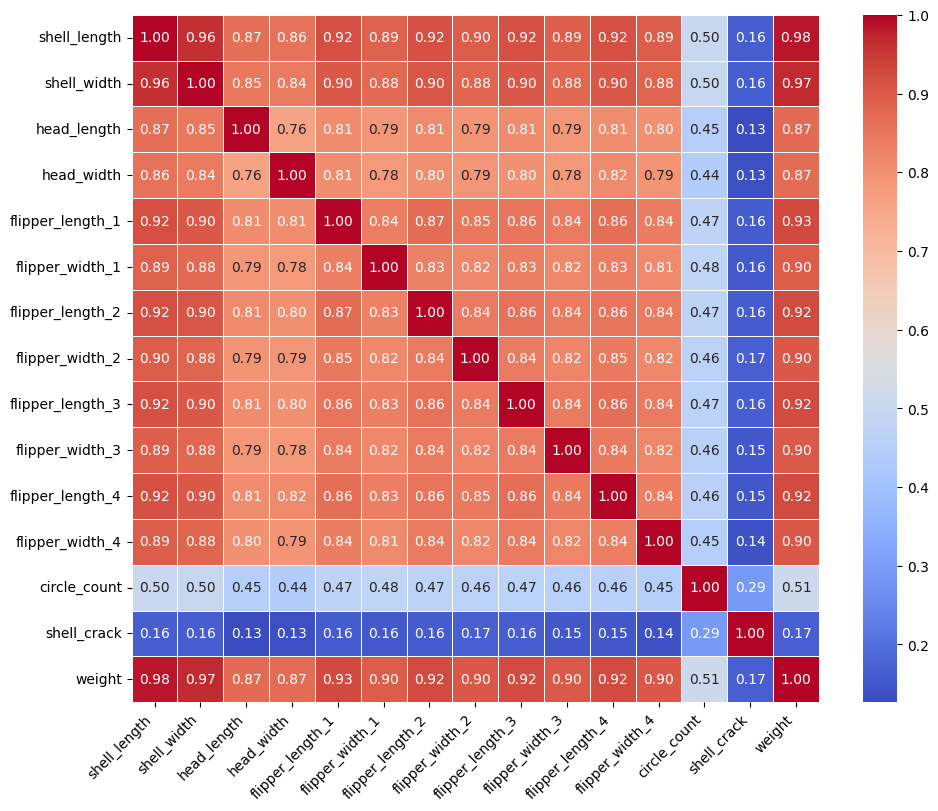

In [85]:
def draw_heatmap_for_corr(df):
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        data=df,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        square=True,
        linewidths=.5
    )
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.show()

draw_heatmap_for_corr(data_cm_corr)

Признак shell_crack имеет очень слабую линейную связь с таргетом и, вероятно, не будет вносить значимого вклада в линейную модель, поэтому его можно удалить.

Признак circle_count имеет умеренную корреляцию с таргетом, однако существенно уступает другим признакам. Его удаление допустимо в будущем, на этапе улучшения модели. На текущем этапе оставим

In [86]:
# Удаление признака shell_crack
data_cm.drop(columns=['shell_crack'], inplace=True)

### 9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

Посмотрим на тепловую карту корреляций еще раз:

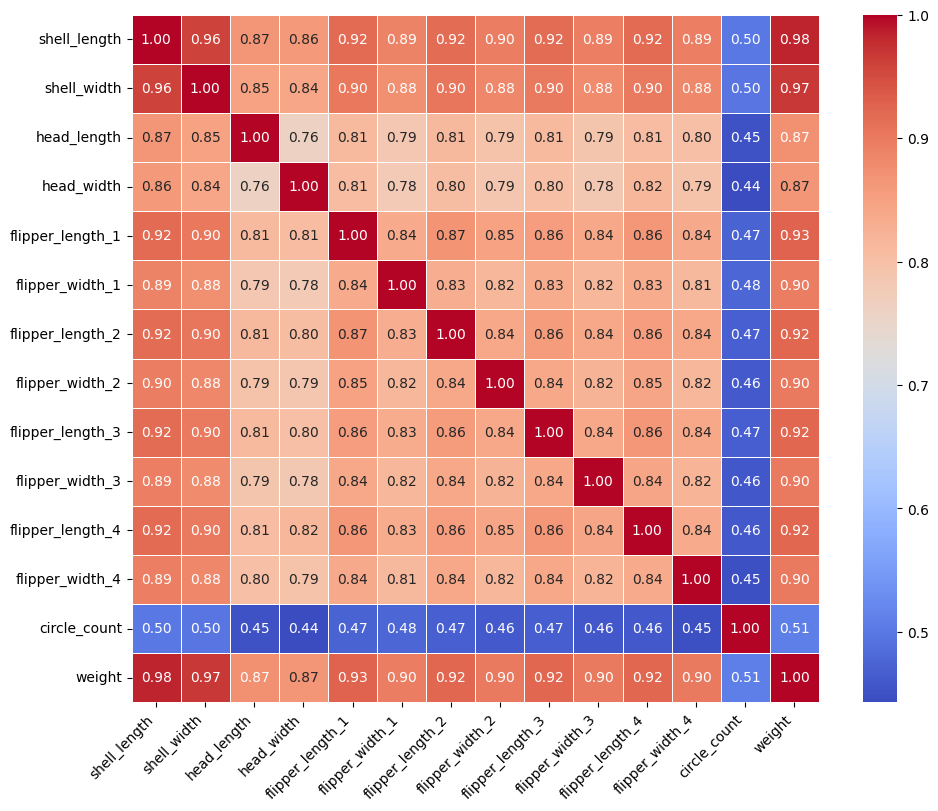

In [87]:
draw_heatmap_for_corr(data_cm.corr())

Мультиколлинеарность явно присутствует. Это логично, так как длина и ширина ласт, головы и панциря часто связаны примерно одинаковой пропорцией.

Попробуем уменьшить мультиколлинеарность, уменьшением количества признаков, вместо длины и ширины будем считать площадь

In [88]:
# Функция для получения новых колонок, путем перемножения двух текущих с последующим их удалением
def multiply_cols(
    df: pd.DataFrame,
    cols_info: list[tuple[str, str, str]]
) -> pd.DataFrame:
    """
    cols_info - список кортежей (col1, col2, col_result),
    где col1 и col2 перемножаются, результат записывается в col_result.
    """
    df = df.copy()

    for col1, col2, col_result in cols_info:
        df[col_result] = df[col1] * df[col2]

    cols_to_drop = {col for col_pair in cols_info for col in col_pair[:2]}
    df.drop(columns=list(cols_to_drop), inplace=True, errors='ignore')

    return df

In [89]:
# Применение функции перемножения
data_areas = multiply_cols(
    data_cm,
    [
        ('shell_length', 'shell_width', 'shell_area'),
        ('head_width', 'head_length', 'head_area'),
        ('flipper_length_1', 'flipper_width_1', 'flipper_1_area'),
        ('flipper_length_2', 'flipper_width_2', 'flipper_2_area'),
        ('flipper_length_3', 'flipper_width_3', 'flipper_3_area'),
        ('flipper_length_4', 'flipper_width_4', 'flipper_4_area'),

    ]
)

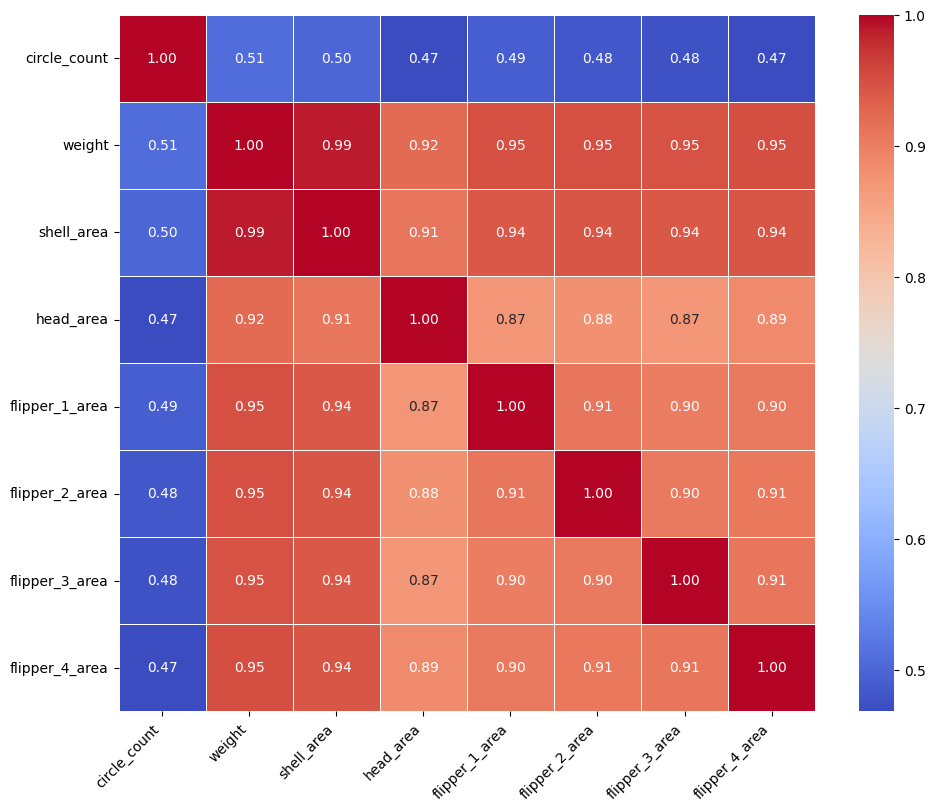

In [90]:
# Снова посмотрим на корреляции

draw_heatmap_for_corr(data_areas.corr())

Площади (shell_area, head_area, flipper_*) сильно коррелируют как с таргетом, так и между собой, что указывает на наличие мультиколлинеарности и дублирующей информации. На текущем этапе признаки можно оставить, однако при обучении модели следует использовать регуляризацию (Ridge или Lasso), которая снизит влияние избыточных признаков и стабилизирует модель.

При этом с высокой вероятностью для построения качественной модели будет достаточно только shell_area, так как этот признак имеет максимальную корреляцию с весом и отражает общий размер черепахи, а остальные площади по сути являются его производными и не несут принципиально новой информации.

## Предобработка данных

1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

### 1. Разделите данные на выборки

In [91]:
# Разделение данных на выборки согласно условию

from sklearn.model_selection import train_test_split

X = data_areas.drop(columns=['weight'])
y = data_areas['weight']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

### 2. Обработайте пропуски

In [93]:
# Применение функции ко всем признакам. В таргете (weight) пропуски удалены заранее
X_train = X_train.fillna(X_train.median(numeric_only=True))

# Сохранение медиан обучающей выборки для использования при предсказании на новых данных
train_medians = X_train.median(numeric_only=True)

# В validate и test передаем медиану из train выборки
X_val = X_val.fillna(train_medians)
X_test = X_test.fillna(train_medians)

In [94]:
# Проверка отсутствия пропусков
X_train.isna().any().any(), X_val.isna().any().any(), X_test.isna().any().any()

(np.False_, np.False_, np.False_)

Пропуски заполнены медианным значением

### 3. Напишите функцию для стандартизации признаков

In [95]:
# Класс StandardScaler вместо функции. Аналог StandardScaler из sklearn

class StandardScaler:
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values

        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)

        return self

    def transform(self, X):
        is_df = isinstance(X, pd.DataFrame)
        columns = X.columns if is_df else None
        index = X.index if is_df else None

        if is_df:
            X = X.values

        X_scaled = (X - self.mean_) / self.std_

        if is_df:
            return pd.DataFrame(X_scaled, columns=columns, index=index)

        return X_scaled

    def fit_transform(self, X):
        return self.fit(X).transform(X)

### 4. Напишите функцию для нормализации признаков

In [96]:
# Класс MinMaxScaler вместо функции. Аналог MinMaxScaler из sklearn

class MinMaxScaler:
    def __init__(self):
        self.min_ = None
        self.max_ = None

    def fit(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values

        self.min_ = np.min(X, axis=0)
        self.max_ = np.max(X, axis=0)

        return self

    def transform(self, X):
        is_df = isinstance(X, pd.DataFrame)
        columns = X.columns if is_df else None

        if is_df:
            X = X.values

        X_scaled = (X - self.min_) / (self.max_ - self.min_)

        if is_df:
            return pd.DataFrame(X_scaled, columns=columns)

        return X_scaled

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [97]:
standard_scaler = StandardScaler()
standard_scaler.fit(X_train)

min_max_scaler = MinMaxScaler()
min_max_scaler.fit(X_train)

X_samples = {
    'default': {
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test
    },
    'standard': {
        'X_train': standard_scaler.transform(X_train),
        'X_val': standard_scaler.transform(X_val),
        'X_test': standard_scaler.transform(X_test)
    },
    'minmax': {
        'X_train': min_max_scaler.transform(X_train),
        'X_val': min_max_scaler.transform(X_val),
        'X_test': min_max_scaler.transform(X_test)
    }
}

## Обучение моделей

1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
   
   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- Бонусное задание. Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета - оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика - MAE, дополнительные - MSE, R², MAPE и прочие.

### 1. Постройте базовую модель (дамми)

In [98]:
# Dummy модель, которая всегда возвращает среднее значение из выборки

class DummyModel:
    def __init__(self):
        self.mean_ = None

    def fit(self, X, y):
        self.mean_ = np.mean(y)
        return self

    def predict(self, X):
        return np.full(len(X), self.mean_)

In [99]:
dummy = DummyModel()
dummy.fit(X_samples['default']['X_train'], y_train)
dummy.mean_

np.float64(96.01551649831652)

### 2. Обучите несколько архитектур линейных моделей

In [100]:
# Перебор моделей
# Перебор стандартизаций
# Перебор squared_error и epsilon_insensitive

from sklearn.linear_model import LinearRegression, Lasso, Ridge, SGDRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

result_rows = []

models = [DummyModel, LinearRegression, Lasso, Ridge, SGDRegressor]
losses = ['squared_error', 'epsilon_insensitive']

for standardization_name, sample in X_samples.items():
    X_train_cur = sample['X_train']
    X_val_cur = sample['X_val']

    for model_cls in models:
        # Для SGDRegressor перебираем loss
        if model_cls == SGDRegressor:
            for loss in losses:
                model = model_cls(loss=loss, random_state=42)
                model.fit(X_train_cur, y_train)

                y_pred = model.predict(X_val_cur)

                result_rows.append({
                    'model': model_cls.__name__,
                    'standardization': standardization_name,
                    'loss': loss,
                    'mae': mean_absolute_error(y_val, y_pred),
                    'mse': mean_squared_error(y_val, y_pred),
                    'r2': r2_score(y_val, y_pred),
                    'mape': mean_absolute_percentage_error(y_val, y_pred)
                })
        else:
            model = model_cls()
            model.fit(X_train_cur, y_train)

            y_pred = model.predict(X_val_cur)

            result_rows.append({
                'model': model_cls.__name__,
                'standardization': standardization_name,
                'loss': None,
                'mae': mean_absolute_error(y_val, y_pred),
                'mse': mean_squared_error(y_val, y_pred),
                'r2': r2_score(y_val, y_pred),
                'mape': mean_absolute_percentage_error(y_val, y_pred)
            })

result = pd.DataFrame(result_rows).sort_values('mse')
result

,model,standardization,loss,mae,mse,r2,mape
10,SGDRegressor,standard,squared_error,3.639712e+00,2.626429e+01,9.769931e-01,3.836089e-02
9,Ridge,standard,NaN,3.629092e+00,2.630111e+01,9.769608e-01,3.847331e-02
1,LinearRegression,default,NaN,3.626709e+00,2.630977e+01,9.769533e-01,3.843699e-02
7,LinearRegression,standard,NaN,3.626709e+00,2.630977e+01,9.769533e-01,3.843699e-02
13,LinearRegression,minmax,NaN,3.626709e+00,2.630977e+01,9.769533e-01,3.843699e-02
3,Ridge,default,NaN,3.626709e+00,2.630977e+01,9.769533e-01,3.843699e-02
15,Ridge,minmax,NaN,3.661723e+00,2.631607e+01,9.769477e-01,3.903673e-02
2,Lasso,default,NaN,3.631428e+00,2.633860e+01,9.769280e-01,3.848069e-02
16,SGDRegressor,minmax,squared_error,3.725271e+00,2.673916e+01,9.765771e-01,3.971706e-02
11,SGDRegressor,standard,epsilon_insensitive,3.746767e+00,2.717410e+01,9.761961e-01,3.933446e-02


## Сравнение моделей на валидационной выборке

1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

Модели показали практически одинаковое качество: R² ~= 0.976, MAE ~= 3.6, MSE ~= 26. Это говорит о том, что зависимость в данных хорошо описывается линейной моделью, и усложнение алгоритмов не дает заметного прироста. Наилучшие результаты стабильно достигаются при использовании стандартизации (StandardScaler), что подтверждает важность приведения признаков к одному масштабу.

SGDRegressor в отдельных случаях показал худшие результаты, вплоть до значений хуже baseline (DummyModel), из-за отсутствия масштабирования и чувствительности к параметрам обучения. В отличие от него, LinearRegression и Ridge работают стабильно и не требуют тонкой настройки. Поэтому оптимальным выбором является простая линейная модель со стандартизацией, например Ridge + StandardScaler или LinearRegression + StandardScaler.

SGDRegressor использует итеративный метод оптимизации (градиентный спуск), поэтому его качество сильно зависит от масштаба данных и гиперпараметров (learning rate, количество итераций и др.). Без корректной настройки он может не сойтись, что приводит к деградации качества модели. При этом при правильной настройке и стандартизации он способен показывать сопоставимые результаты, однако в рамках данной задачи его использование избыточно по сравнению с более простыми и стабильными моделями.

Далее будем использовать Ridge + StandardScaler

## Проверка лучшей модели на тестовой выборке

1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.

In [101]:
model = Ridge(random_state=42)
model.fit(X_samples['standard']['X_train'], y_train)

y_pred = model.predict(X_samples['standard']['X_test'])

metrics = {
    'mae': mean_absolute_error(y_test, y_pred),
    'mse': mean_squared_error(y_test, y_pred),
    'rmse': mean_squared_error(y_test, y_pred) ** 0.5,
    'r2': r2_score(y_test, y_pred),
    'mape': mean_absolute_percentage_error(y_test, y_pred)
}

metrics

{'mae': 3.6171022451427923,
 'mse': 26.78001981438057,
 'rmse': 5.1749415276291355,
 'r2': 0.9770940862266116,
 'mape': 0.037190655369891815}

Лучшая модель (Ridge + StandardScaler) демонстрирует качество, удовлетворяющее заданным требованиям: значение MAE ~= 3.6 кг, что значительно ниже допустимого порога в 5 кг для целевой популяции зелёных морских черепах. Это означает, что в среднем ошибка предсказания массы находится в приемлемых пределах и модель пригодна для практического использования с точки зрения абсолютной точности.

С учётом того, что масса черепах существенно варьируется в зависимости от возраста и размера, дополнительно была проанализирована относительная ошибка. Значение MAPE ~= 3.8% показывает, что модель сохраняет стабильную точность на разных масштабах признаков и не искажает прогнозы для мелких и крупных особей. Это подтверждает её универсальность для всей рассматриваемой популяции.

Также модель демонстрирует высокую объясняющую способность: R² ~= 0.976 на валидационной выборке, что превышает требуемый порог 0.97. Это означает, что модель объясняет большую часть вариативности массы черепах и хорошо улавливает зависимость между признаками и целевой переменной. Таким образом, выбранная модель соответствует всем критериям и рекомендуется к внедрению.

## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

In [102]:
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef': model.coef_
})
coef_df.sort_values('coef', ascending=False)

,feature,coef
1,shell_area,13.989915
3,flipper_1_area,5.486343
4,flipper_2_area,5.063826
5,flipper_3_area,3.899617
2,head_area,3.714881
6,flipper_4_area,3.503932
0,circle_count,0.719367


In [103]:
coef_intercept = model.intercept_
coef_intercept

np.float64(96.01551649831652)

Полученные коэффициенты подтверждают наличие мультиколлинеарности между признаками площадей: все переменные группы shell_area, flipper_*, head_area имеют положительные и сопоставимые по масштабу коэффициенты, что говорит о том, что модель распределяет вклад между коррелирующими признаками.

При этом наибольший коэффициент у shell_area (~14), что подтверждает гипотезу о том, что именно этот признак является основным фактором, определяющим вес черепахи. Остальные площади вносят дополнительный вклад, но их влияние частично дублирует информацию о размере, уже содержащуюся в shell_area.

Наличие ненулевых коэффициентов у всех признаков также показывает, что регуляризация (в данном случае Ridge) не занулила их полностью, а лишь сгладила веса, перераспределив вклад между коррелирующими переменными.

Признак circle_count имеет значительно меньший коэффициент (~0.7), что указывает на его слабое влияние на целевую переменную по сравнению с геометрическими характеристиками.

## Функция для прогнозирования веса черепахи

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

In [104]:
# Функция для подготовки изначальных данных к формату, на котором обучалась модель
def prepare_data(df):
    df = df.copy()

    # Отбор требуемого вида черепах
    df['binomial_name'] = df['binomial_name'].str.lower()
    df = df[df['binomial_name']=='chelonia mydas']

    # Удаление лишних признаков
    df = df.drop(
        columns=[
            'id',
            'binomial_name',
            'registration number',
            'measure_count',
            'timestamp',
            'shell_crack'
        ],
        errors='ignore'
    )

    # Замена нулей на NaN
    df = df.replace(0, np.nan)

    # Коррекция аномальных значений shell_length и shell_width (деление на 10)
    cols = ['shell_length', 'shell_width']
    df[cols] = df[cols].apply(pd.to_numeric, errors='coerce', downcast='float')
    anomaly_mask = (
        (df['shell_length'] > df['shell_length'].quantile(.99))
        & (df['shell_width'] > df['shell_width'].quantile(.99))
    )
    df.loc[anomaly_mask, cols] = (df.loc[anomaly_mask, cols] / 10).round(2)

    # Вычисление комбинированных признаков
    df = multiply_cols(
        df,
        [
            ('shell_length', 'shell_width', 'shell_area'),
            ('head_width', 'head_length', 'head_area'),
            ('flipper_length_1', 'flipper_width_1', 'flipper_1_area'),
            ('flipper_length_2', 'flipper_width_2', 'flipper_2_area'),
            ('flipper_length_3', 'flipper_width_3', 'flipper_3_area'),
            ('flipper_length_4', 'flipper_width_4', 'flipper_4_area'),
        ]
    )

    # Только необходимые признаки
    df = df[['circle_count', 'shell_area', 'head_area', 'flipper_1_area', 'flipper_2_area', 'flipper_3_area', 'flipper_4_area']]

    # Заполнение пропусков медианами обучающей выборки
    df = df.fillna(train_medians)

    # Стандартизация
    df = standard_scaler.transform(df)

    return df


# Функция для предсказания веса черепах по изначальным данным
def predict(df):
    result = pd.Series(coef_intercept, index=df.index)

    for _, row in coef_df.iterrows():
        result += row['coef'] * df[row['feature']]

    return result

In [105]:
# Применение кастомной функции предсказания

# Для замера метрик нужно подготовить данные дополнительно.
# При реальном использовании достаточно передать данные в функцию predict
X = prepare_data(data[data['weight'] > 0])
y = data[(data['weight'] > 0) & (data['binomial_name']=='chelonia mydas')]['weight']

# Вызов кастомной функции предсказания
y_pred = predict(X)

# Замер метрик
metrics = {
    'mae': round(mean_absolute_error(y, y_pred),2),
    'mse': round(mean_squared_error(y, y_pred),2),
    'rmse': round(mean_squared_error(y, y_pred) ** 0.5,2),
    'r2': round(r2_score(y, y_pred),2),
    'mape': round(mean_absolute_percentage_error(y, y_pred),2)
}

metrics

{'mae': 3.63, 'mse': 38.13, 'rmse': 6.17, 'r2': 0.97, 'mape': 0.04}

## Общие выводы и рекомендации по дальнейшей работе

Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.

### Какие модели изучены?

В рамках проекта были исследованы три модели линейной регрессии из библиотеки scikit-learn:

- LinearRegression - классическая линейная регрессия (метод наименьших квадратов);
- Ridge - линейная регрессия с L2-регуляризацией;
- SGDRegressor - линейная регрессия на основе стохастического градиентного спуска.

Каждая модель была обучена в трёх вариантах предобработки данных: без масштабирования (default), со стандартизацией (StandardScaler) и с нормализацией (MinMaxScaler). Итого было проведено 18 экспериментов (3 модели × 3 способа масштабирования × 2 функции потерь для SGDRegressor).

### Какие результаты получены?

Все три модели в оптимальных конфигурациях показали схожие результаты на валидационной выборке: MAE ~= 3.6 кг, R² ~= 0.977, MAPE ~= 3.8%. LinearRegression и Ridge демонстрируют стабильное качество вне зависимости от способа масштабирования, тогда как SGDRegressor чувствителен к настройке гиперпараметров и масштабу данных - без стандартизации его качество значительно деградирует.

На тестовой выборке лучшая модель (Ridge + StandardScaler) подтвердила результаты: MAE ~= 3.63 кг, RMSE ~= 6.17 кг, R² ~= 0.97, MAPE ~= 4%. Признаков переобучения не обнаружено - метрики на обучающей, валидационной и тестовой выборках сопоставимы.

### Рекомендуется ли итоговая модель к внедрению?

Да, модель рекомендуется к внедрению. Все установленные критерии успешности выполнены:

- MAE ~= 3.63 кг - значительно ниже допустимого порога в 5 кг;
- R² ~= 0.97 - на уровне требуемого значения 0.97;
- MAPE ~= 4% - модель сохраняет стабильную точность для черепах разного размера и возраста.

Модель проста в интерпретации, устойчива и не демонстрирует признаков переобучения, что делает её пригодной для практического использования.

### Какая архитектура и способ обработки признаков показали себя лучше всего?

Лучшей комбинацией стала Ridge + StandardScaler. Ключевые решения в обработке признаков:

- Исходные парные признаки длины и ширины (панциря, головы, ластов) были объединены в площадные признаки (shell_area, head_area, flipper_1_area ... flipper_4_area), что позволило создать более информативные предикторы;
- Пропуски заполнены медианами обучающей выборки;
- Аномальные значения shell_length и shell_width скорректированы делением на 10 (ошибка в единицах измерения);
- Применена стандартизация (StandardScaler), которая обеспечила корректную работу регуляризации в Ridge.

Показатели метрик лучшей модели на тестовой выборке: MAE = 3.63 кг, MSE = 38.13, RMSE = 6.17 кг, R² = 0.97, MAPE = 4%.

### Какие признаки наиболее важны для модели?

По абсолютным значениям коэффициентов модели Ridge (на стандартизированных данных):

1. shell_area (~= 14.0) - площадь панциря является доминирующим предиктором, что биологически обосновано: размер панциря напрямую связан с массой тела черепахи;
2. flipper_1_area (~= 5.5) и flipper_2_area (~= 5.1) - площади передних ластов;
3. flipper_3_area (~= 3.9) и head_area (~= 3.7) - площади задних ластов и головы;
4. flipper_4_area (~= 3.5);
5. circle_count (~= 0.7) - количество колец на панцире имеет наименьший вклад.

Наличие мультиколлинеарности между площадными признаками подтверждается положительными и сопоставимыми коэффициентами, однако Ridge-регуляризация корректно распределяет вклад между коррелирующими переменными.

### Есть ли перспективы у обучения моделей для предсказания массы других видов черепах?

Да, перспективы есть. В датасете помимо Chelonia mydas представлены данные о других видах (Caretta caretta, Lepidochelys olivacea и др.). Однако для построения качественных моделей для каждого вида необходимо:

- Провести отдельный EDA для каждого вида, так как зависимости между размерами и массой могут существенно различаться;
- Убедиться в достаточном объёме данных для каждого вида;
- Возможно, скорректировать набор признаков и параметры регуляризации.

Альтернативный подход - построить единую модель для всех видов, включив вид черепахи в качестве категориального признака (one-hot encoding), что позволит модели учитывать межвидовые различия.

### Предложения по дальнейшему развитию проекта

1. Кросс-валидация. Применить k-fold кросс-валидацию для более надёжной оценки качества модели и снижения зависимости результата от конкретного разбиения данных.
2. Подбор гиперпараметров. Провести систематический подбор параметра регуляризации alpha для Ridge (например, с помощью GridSearchCV или RidgeCV) вместо использования значения по умолчанию.
3. Мониторинг в продакшене. При внедрении модели организовать систему мониторинга качества предсказаний на новых данных для своевременного выявления деградации модели.